[[2.  2.2]
 [3.  3.1]
 [4.  4.2]
 [5.  4.8]
 [6.  6.1]
 [7.  6.9]
 [8.  8.2]
 [9.  8.8]]
(8, 2)


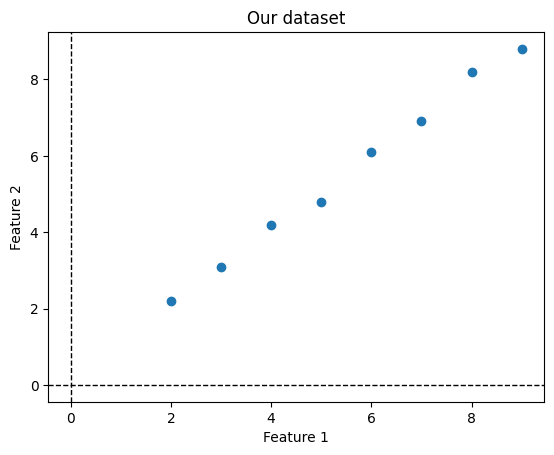

In [19]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [2.0, 2.2],
    [3.0, 3.1],
    [4.0, 4.2],
    [5.0, 4.8],
    [6.0, 6.1],
    [7.0, 6.9],
    [8.0, 8.2],
    [9.0, 8.8],
])

print(X)
print(X.shape)

fig, ax = plt.subplots()

ax.scatter(x=X[:,0], y=X[:,1])

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(0, color='black', linewidth=1, linestyle='--')

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Our dataset")
plt.show()

We have to first center our data

In [20]:
mean = np.mean(X, axis=0)
print(mean)

X_centered = X - mean
print(X_centered)

print(np.mean(X_centered, axis = 0))

[5.5    5.5375]
[[-3.5    -3.3375]
 [-2.5    -2.4375]
 [-1.5    -1.3375]
 [-0.5    -0.7375]
 [ 0.5     0.5625]
 [ 1.5     1.3625]
 [ 2.5     2.6625]
 [ 3.5     3.2625]]
[0.0000000e+00 4.4408921e-16]


The off-diagonal values are large and positive because the two features move together.

Think about what happens after centering:

When Feature 1 is below its mean, Feature 2 is also generally below its mean.
When Feature 1 is above its mean, Feature 2 is also generally above its mean.

So when we multiply corresponding centered values:

we mostly get positive numbers:

(-)(-) = + 

and

(+)(+) = +

Those positive products accumulate to give:

40.5

That's why the off-diagonal entries are large and positive.

So you can start reading

X_c^T.X_c =  42 & 40.5 40.5 & 39.94875 

like this:

Entry	        Meaning
42	            Variation of Feature 1
39.94875	    Variation of Feature 2
40.5	        How Feature 1 and Feature 2 move together
40.5	        Same relationship, viewed from the other direction

And notice something interesting:

40.5

is almost as large as the individual variation values:

42, 39.95

That is telling us there is a very strong relationship between these two features.

In [21]:
XTX = X_centered.T @ X_centered
print(XTX)

[[42.      40.55   ]
 [40.55    39.31875]]


In [22]:
eigenvalues, eigenvectors = np.linalg.eig(XTX)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[81.23153017  0.08721983]

Eigenvectors:
[[ 0.7186943  -0.69532619]
 [ 0.69532619  0.7186943 ]]


The code below is going to carry out dimensionality reduction

In [23]:
v1 = eigenvectors[:,0]
X_reduced = X_centered @ v1

print(X_reduced)
print(X_reduced.shape)

[-4.83608119 -3.49159333 -2.00804022 -0.87215021  0.75046813  2.02542338
  3.64804172  4.78393173]
(8,)


In [24]:
X_reconstructed = np.outer(X_reduced, v1)

print(X_reconstructed)

[[-3.47566397 -3.3626539 ]
 [-2.50938821 -2.42779628]
 [-1.44316705 -1.39624295]
 [-0.62680938 -0.60642888]
 [ 0.53935716  0.52182014]
 [ 1.45566023  1.40832992]
 [ 2.62182677  2.53657894]
 [ 3.43818444  3.32639302]]


Now let us visualize the data

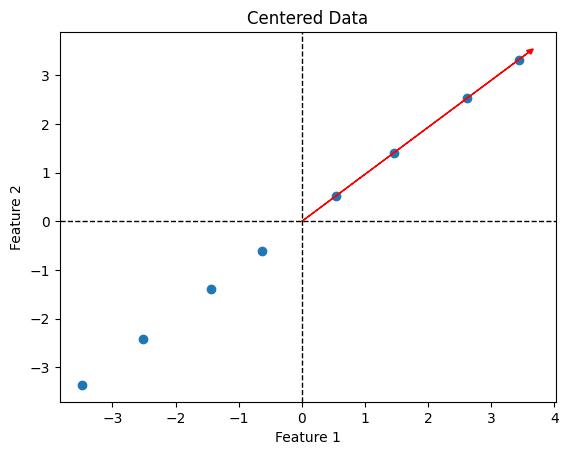

In [25]:
fig, ax = plt.subplots()

ax.scatter(x=X_reconstructed[:,0], y=X_reconstructed[:,1])

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(0, color='black', linewidth=1, linestyle='--')

scale = 5 
ax.arrow(0, 0, v1[0] * scale, v1[1] * scale, head_width=0.1, head_length=0.1, fc='red', ec='red')


ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Centered Data")
plt.show()

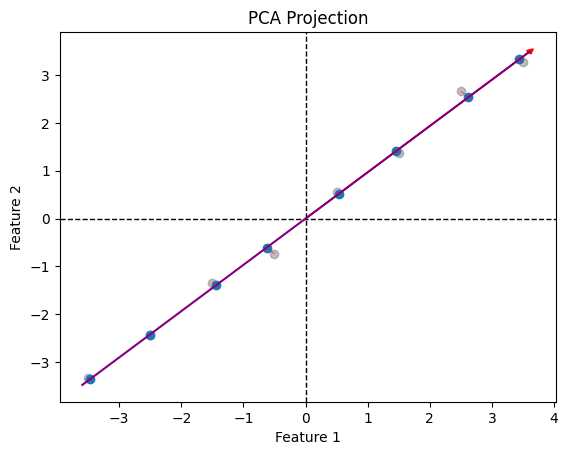

In [29]:
fig, ax = plt.subplots()

ax.scatter(x=X_centered[:, 0], y=X_centered[:, 1], color='gray', alpha=0.5, label="Original Data")

ax.scatter(x=X_reconstructed[:,0], y=X_reconstructed[:,1])

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(0, color='black', linewidth=1, linestyle='--')

scale = 5 
ax.plot(
    [-v1[0] * scale, v1[0] * scale],
    [-v1[1] * scale, v1[1] * scale], 
    color='purple',
    linewidth=1.5,
    label="v1 Axis Line")

ax.arrow(0, 0, v1[0] * scale, v1[1] * scale,
         head_width=0.1,
         head_length=0.1,
         fc='red',
         ec='red')

for original, projected in zip(X_centered, X_reconstructed):
    ax.plot(
        [original[0], projected[0]],
        [original[1], projected[1]],
        color="red",
        linestyle="--",
        linewidth=0.8,
        alpha=0.6
    )


ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("PCA Projection")
plt.show()